# CNN-ResBiGRU (IMU-Only, PyTorch)
## Gym Exercise Activity Recognition

**Based on:** Mekruksavanich & Jitpattanakul (2024), *Appl. Syst. Innov.*, 7(4), 59.  
**DOI:** https://doi.org/10.3390/asi7040059

Adapted to **Scenario III** (accelerometer + gyroscope only), which achieved **96.96% accuracy** and **91.78% F1-score** on the Myogym dataset.

### Architecture (Figure 5)
```
Input (window_size × C channels)
  → [Conv1D → BatchNorm → ReLU → MaxPool1D → Dropout] × 4
  → ResBiGRU (2 stacked BiGRU layers with residual + LayerNorm)
  → Global Average Pooling
  → Dense(128, ReLU) → Dropout(0.5)
  → Dense(num_classes)
```

---
## 0. Setup & Configuration

In [17]:
# Uncomment to install dependencies if needed:
# !pip install torch scikit-learn scipy numpy pandas

In [18]:
import numpy as np
import torch
import torch.nn as nn
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu126
CUDA:    True
Device:  cuda


In [19]:
# ============================================================
# CONFIGURATION — edit these to match your setup
# ============================================================
SAMPLING_RATE    = 50       # Hz — your IMU's sampling frequency
NUM_IMU_CHANNELS = 6        # 6=accel+gyro, 3=accel only, 9=+magnetometer
NUM_CLASSES      = 2       # number of exercises you're classifying
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap between windows
EPOCHS           = 100      # max training epochs
BATCH_SIZE       = 32
N_FOLDS          = 5        # cross-validation folds
LEARNING_RATE    = 1e-3
PATIENCE         = 15       # early stopping patience

---
## 1. Data Preprocessing (Section 3.3)

In [20]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU-only data.

    Steps (Section 3.3):
      1. Denoising   — 6th-order zero-phase Butterworth bandpass (1–20 Hz)
      2. Normalize    — Per-channel min–max scaling to [0, 1]
      3. Segment      — Sliding window with overlap + majority-vote labels
    """

    def __init__(self, sampling_rate=50, window_size_sec=2.0, overlap=0.5,
                 imu_lowcut=1.0, imu_highcut=20.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)
        self.step_size = int(self.window_size * (1.0 - overlap))
        self.lowcut = imu_lowcut
        self.highcut = imu_highcut
        self.filter_order = filter_order

    # ----- 3.3.1 Denoising -----
    def denoise(self, data):
        """6th-order zero-phase Butterworth bandpass, per channel (1–20 Hz)."""
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            return data.copy()
        b, a = butter(self.filter_order, [lo, hi], btype="band")
        out = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    # ----- 3.3.2 Normalization -----
    def fit_normalize(self, data):
        """Fit per-channel min/max, return normalized data."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data):
        """Apply previously fitted min–max (for test/inference)."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data):
        denom = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    # ----- 3.3.3 Sliding-window segmentation -----
    def segment(self, data, labels):
        """Sliding window with majority-vote labeling."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

    # ----- Full pipeline -----
    def preprocess(self, imu_data, labels):
        """Denoise → normalize → segment."""
        denoised = self.denoise(imu_data)
        normalized = self.fit_normalize(denoised)
        return self.segment(normalized, labels)

---
## 2. Model Architecture (Section 3.4)

In [21]:
class ResBiGRUBlock(nn.Module):
    """
    Residual Bidirectional GRU block (Section 3.4.2, Figure 6, Eqs. 4-6).

    Each stacked layer:
        h = BiGRU(x)           # forward + backward GRU, concatenated
        r = Linear(x)          # project input to match h's dimension
        x = LayerNorm(r + h)   # residual connection + normalization
    """

    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2  # BiGRU output: 2 * hidden

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)       # (B, T, 2*hidden)
            r = blk["proj"](x)         # (B, T, 2*hidden)
            x = blk["ln"](r + h)       # residual + LayerNorm
        return x

In [22]:
class CNNResBiGRU(nn.Module):
    """
    CNN-ResBiGRU model (Section 3.4, Figure 5).

    Input:  (batch, seq_len, in_channels)
    Output: (batch, num_classes) — raw logits (use CrossEntropyLoss)
    """

    def __init__(self, in_channels=6, num_classes=31,
                 conv_filters=(64, 128, 256, 512), kernel=3, pool=2,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128):
        super().__init__()

        # 4 × Convolution Blocks (Section 3.4.1)
        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.MaxPool1d(pool),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        # Residual BiGRU (Section 3.4.2)
        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)         # (B, T, C) → (B, C, T) for Conv1d
        x = self.conv(x)
        x = x.permute(0, 2, 1)         # back to (B, T', C') for GRU
        x = self.resbigru(x)           # (B, T', 2*gru_units)
        x = x.mean(dim=1)              # global average pooling
        return self.head(x)

---
## 3. Baseline Models (Tables 2–6)

In [23]:
class CNNBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31):
        super().__init__()
        blocks = []
        ch = in_channels
        for f in [64, 128, 256, 512]:
            blocks += [nn.Conv1d(ch, f, 3, padding=1), nn.BatchNorm1d(f),
                       nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3)]
            ch = f
        self.conv = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(ch, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)).mean(dim=2))


class LSTMBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.LSTM(in_channels, hidden, num_layers=2, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class BiLSTMBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.LSTM(in_channels, hidden, num_layers=2,
                           batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class GRUBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.GRU(in_channels, hidden, num_layers=2, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class BiGRUBaseline(nn.Module):
    def __init__(self, in_channels=6, num_classes=31, hidden=128):
        super().__init__()
        self.rnn = nn.GRU(in_channels, hidden, num_layers=2,
                          batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])

---
## 4. Ablation Variants (Section 5.1)

In [24]:
class NoConvResBiGRU(nn.Module):
    """Ablation: ResBiGRU only, no convolution blocks (Table 7)."""

    def __init__(self, in_channels=6, num_classes=31, gru_units=128,
                 gru_layers=2, dense=128):
        super().__init__()
        self.resbigru = ResBiGRUBlock(in_channels, gru_units, gru_layers)
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(dense, num_classes))

    def forward(self, x):
        return self.head(self.resbigru(x).mean(dim=1))


class CNNNoResBiGRU(nn.Module):
    """Ablation: CNN only, no ResBiGRU block (Table 8)."""

    def __init__(self, in_channels=6, num_classes=31,
                 conv_filters=(64, 128, 256, 512), conv_drop=0.3, dense=128):
        super().__init__()
        blocks = []
        ch = in_channels
        for f in conv_filters:
            blocks += [nn.Conv1d(ch, f, 3, padding=1), nn.BatchNorm1d(f),
                       nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(conv_drop)]
            ch = f
        self.conv = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(ch, dense), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(dense, num_classes))

    def forward(self, x):
        return self.head(self.conv(x.permute(0, 2, 1)).mean(dim=2))

In [25]:
ALL_MODELS = {
    "cnn_resbigru": CNNResBiGRU,
    "cnn":          CNNBaseline,
    "lstm":         LSTMBaseline,
    "bilstm":       BiLSTMBaseline,
    "gru":          GRUBaseline,
    "bigru":        BiGRUBaseline,
    "no_conv":      NoConvResBiGRU,
    "no_resbigru":  CNNNoResBiGRU,
}

print(f"Available models: {list(ALL_MODELS.keys())}")

Available models: ['cnn_resbigru', 'cnn', 'lstm', 'bilstm', 'gru', 'bigru', 'no_conv', 'no_resbigru']


---
## 5. Training & Evaluation (5-Fold CV, Section 3.3.4)

In [26]:
def train_evaluate(X, y, num_classes, model_name="cnn_resbigru",
                   n_folds=5, epochs=100, batch_size=64, patience=15,
                   lr=1e-3, device=None, verbose=True):
    """
    5-fold cross-validation training and evaluation.

    Args:
        X:            (N, window_size, channels) numpy array.
        y:            (N,) integer labels numpy array.
        num_classes:  Number of activity classes.
        model_name:   Key from ALL_MODELS dict.
        n_folds:      Number of CV folds.
        epochs:       Max training epochs.
        batch_size:   Batch size.
        patience:     Early stopping patience.
        lr:           Learning rate.
        device:       torch.device or None (auto-detect).
        verbose:      Print progress.

    Returns:
        Dict with per-fold and averaged metrics.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if verbose:
        print(f"  Device: {device}")

    ModelClass = ALL_MODELS[model_name]
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = {"acc": [], "prec": [], "rec": [], "f1": [], "loss": [],
               "histories": []}

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        if verbose:
            print(f"\n{'─'*50}")
            print(f"  Fold {fold+1}/{n_folds}  "
                  f"(train={len(tr_idx)}, val={len(va_idx)})")
            print(f"{'─'*50}")

        # Build fresh model each fold
        model = ModelClass(in_channels=X.shape[2],
                           num_classes=num_classes).to(device)

        if fold == 0 and verbose:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Model: {model_name}  |  Parameters: {n_params:,}")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

        # Prepare tensors
        X_tr = torch.FloatTensor(X[tr_idx]).to(device)
        y_tr = torch.LongTensor(y[tr_idx]).to(device)
        X_va = torch.FloatTensor(X[va_idx]).to(device)
        y_va = torch.LongTensor(y[va_idx]).to(device)
        train_dl = DataLoader(TensorDataset(X_tr, y_tr),
                              batch_size=batch_size, shuffle=True)

        # Training loop with early stopping
        best_val_loss, wait, best_state = float("inf"), 0, None
        history = {"train_loss": [], "val_loss": [], "val_acc": []}

        for epoch in range(epochs):
            # --- Train ---
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for xb, yb in train_dl:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches += 1
            avg_train_loss = epoch_loss / n_batches

            # --- Validate ---
            model.eval()
            with torch.no_grad():
                val_logits = model(X_va)
                val_loss = loss_fn(val_logits, y_va).item()
                val_acc = (val_logits.argmax(1) == y_va).float().mean().item()

            history["train_loss"].append(avg_train_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            scheduler.step(val_loss)
            cur_lr = optimizer.param_groups[0]["lr"]

            if verbose and (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d}  "
                      f"train_loss={avg_train_loss:.4f}  "
                      f"val_loss={val_loss:.4f}  "
                      f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss, wait = val_loss, 0
                best_state = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print(f"    Early stopping at epoch {epoch+1}")
                    break

        # Restore best weights
        if best_state is not None:
            model.load_state_dict(best_state)
            model = model.to(device)

        # --- Final evaluation ---
        model.eval()
        with torch.no_grad():
            y_pred = model(X_va).argmax(1).cpu().numpy()
        y_true = y[va_idx]

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        results["loss"].append(best_val_loss)
        results["histories"].append(history)

        if verbose:
            print(f"\n  Fold {fold+1} =>  Acc: {acc*100:.2f}%  "
                  f"F1: {f1*100:.2f}%  Loss: {best_val_loss:.4f}")

    # --- Summary ---
    print(f"\n{'='*50}")
    print(f"  {model_name.upper()} — AVERAGE RESULTS ({n_folds}-Fold CV)")
    print(f"{'='*50}")
    for key, label in [("acc", "Accuracy"), ("prec", "Precision"),
                       ("rec", "Recall"), ("f1", "F1-score")]:
        v = np.array(results[key]) * 100
        print(f"  {label:12s}: {v.mean():.2f}% (+/-{v.std():.2f}%)")
    v = np.array(results["loss"])
    print(f"  {'Loss':12s}: {v.mean():.4f} (+/-{v.std():.4f})")

    return results

---
## 6. Load Data

Replace the synthetic data generator below with your actual IMU data.  
Your data should be:
- `imu_data`: numpy array of shape `(T, C)` where `T` = total timesteps, `C` = number of IMU channels (e.g. 6 for accel+gyro)
- `labels`: numpy array of shape `(T,)` with integer class IDs per timestep

In [27]:
def generate_synthetic_imu(n_subjects=10, n_classes=31,
                           samples_per_subj=5000, n_channels=6):
    """Synthetic IMU data for testing. Replace with your real data."""
    np.random.seed(42)
    all_imu, all_y = [], []
    for _ in range(n_subjects):
        channels = []
        if n_channels >= 3:
            channels.append(np.random.randn(samples_per_subj, 3) * 0.8)
        if n_channels >= 6:
            channels.append(np.random.randn(samples_per_subj, 3) * 30.0)
        if n_channels >= 9:
            channels.append(np.random.randn(samples_per_subj, 3) * 50.0)
        imu = np.hstack(channels)[:, :n_channels]
        seg = samples_per_subj // n_classes
        labels = np.repeat(np.arange(n_classes), seg)
        pad = samples_per_subj - len(labels)
        if pad > 0:
            labels = np.concatenate([labels, np.full(pad, n_classes - 1)])
        all_imu.append(imu)
        all_y.append(labels[:samples_per_subj])
    return np.vstack(all_imu), np.concatenate(all_y)


def load_csv_imu(filepath, imu_columns, label_column):
    """
    Load IMU data from a CSV file.

    Example:
        imu_data, labels = load_csv_imu(
            "data.csv",
            imu_columns=["ax", "ay", "az", "gx", "gy", "gz"],
            label_column="activity"
        )
    """
    import pandas as pd
    df = pd.read_csv(filepath)
    imu_data = df[imu_columns].values.astype(np.float64)
    labels = df[label_column].values
    if labels.dtype == object:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        labels = le.fit_transform(labels)
        print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    return imu_data, labels.astype(np.int64)

In [28]:
# ---- Load your data here ----
from scipy.io import loadmat
# Option A: Synthetic (for testing)
# data, labels = generate_synthetic_imu(
#     n_channels=NUM_IMU_CHANNELS, n_classes=NUM_CLASSES)


# MYOGYM ONLY
# imu_data = loadmat('data/gym_data/gym_data1.mat')
# data = imu_data['data1_wrist']
# labels = imu_data['data1_labels']
# print(np.unique(labels))
# Option B: From CSV
data, labels = load_csv_imu(
    "../golden_dataset.csv",
    imu_columns=["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"],
    label_column="excercise"
)

# Option C: From numpy files
# imu_data = np.load("imu_data.npy")   # shape (T, 6)
# labels   = np.load("labels.npy")     # shape (T,)

print(f"IMU data: {data.shape}")
print(f"Labels:   {labels.shape} ({len(np.unique(labels))} classes)")

Label mapping: {'arm_curl': 0, 'bench_press': 1}
IMU data: (317761, 6)
Labels:   (317761,) (2 classes)


---
## 7. Preprocess

In [29]:
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
)

X, y = pp.preprocess(data, labels)

print(f"Windowed data:")
print(f"  X: {X.shape}  (windows × timesteps × channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes)")
print(f"  Value range: [{X.min():.4f}, {X.max():.4f}]")

Windowed data:
  X: (6354, 100, 6)  (windows × timesteps × channels)
  y: (6354,)  (2 classes)
  Value range: [0.0000, 1.0000]


---
## 8. Train CNN-ResBiGRU

In [30]:
results = train_evaluate(
    X, y,
    num_classes=NUM_CLASSES,
    model_name="cnn_resbigru",
    n_folds=N_FOLDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    lr=LEARNING_RATE,
    device=DEVICE,
)

  Device: cuda

──────────────────────────────────────────────────
  Fold 1/5  (train=5083, val=1271)
──────────────────────────────────────────────────
  Model: cnn_resbigru  |  Parameters: 1,540,418
    Epoch  10  train_loss=0.4555  val_loss=2.3273  val_acc=0.6499  lr=1.0e-03
    Epoch  20  train_loss=0.4401  val_loss=0.4867  val_acc=0.6758  lr=5.0e-04
    Epoch  30  train_loss=0.4315  val_loss=6.0873  val_acc=0.5767  lr=2.5e-04
    Epoch  40  train_loss=0.4306  val_loss=0.4524  val_acc=0.7042  lr=6.3e-05
    Early stopping at epoch 41

  Fold 1 =>  Acc: 70.18%  F1: 65.36%  Loss: 0.4489

──────────────────────────────────────────────────
  Fold 2/5  (train=5083, val=1271)
──────────────────────────────────────────────────
    Epoch  10  train_loss=0.4579  val_loss=4.1519  val_acc=0.5712  lr=1.0e-03
    Epoch  20  train_loss=0.4404  val_loss=3.9204  val_acc=0.5759  lr=5.0e-04
    Epoch  30  train_loss=0.4335  val_loss=0.4313  val_acc=0.7002  lr=1.3e-04
    Epoch  40  train_loss=0.4301

---
## 9. Visualize Training Curves

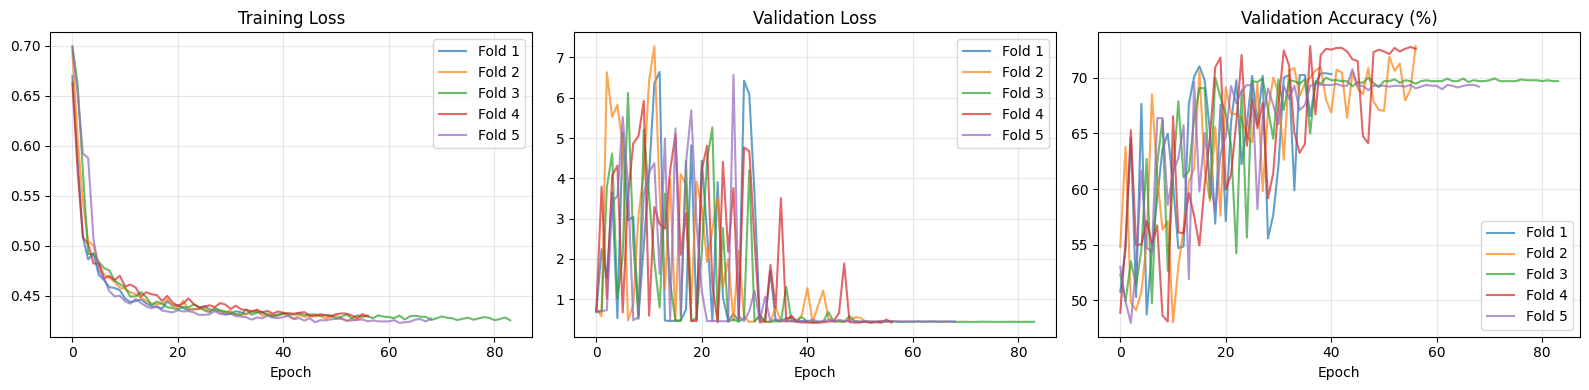

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, hist in enumerate(results["histories"]):
    axes[0].plot(hist["train_loss"], alpha=0.7, label=f"Fold {i+1}")
    axes[1].plot(hist["val_loss"], alpha=0.7, label=f"Fold {i+1}")
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.7, label=f"Fold {i+1}")

axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
axes[1].set_title("Validation Loss"); axes[1].set_xlabel("Epoch")
axes[2].set_title("Validation Accuracy (%)"); axes[2].set_xlabel("Epoch")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. (Optional) Compare All Baseline Models

In [32]:
# Set to True to run the full comparison (takes a while)
RUN_COMPARISON = False

if RUN_COMPARISON:
    comparison = {}
    for name in ["cnn", "lstm", "bilstm", "gru", "bigru", "cnn_resbigru"]:
        print(f"\n{'#'*60}")
        print(f"  Training: {name}")
        print(f"{'#'*60}")
        comparison[name] = train_evaluate(
            X, y, num_classes=NUM_CLASSES, model_name=name,
            epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
            verbose=False,
        )

    # Summary table
    print(f"\n{'Model':<18} {'Accuracy':>12} {'F1-score':>12} {'Loss':>10}")
    print("─" * 55)
    for name, res in comparison.items():
        acc = np.mean(res['acc']) * 100
        f1 = np.mean(res['f1']) * 100
        loss = np.mean(res['loss'])
        print(f"  {name:<16} {acc:>10.2f}% {f1:>10.2f}% {loss:>10.4f}")

---
## 11. (Optional) Ablation Study

In [33]:
# Set to True to run ablation experiments
RUN_ABLATION = False

if RUN_ABLATION:
    ablation = {}
    for name in ["no_conv", "no_resbigru", "cnn_resbigru"]:
        print(f"\n{'#'*60}")
        print(f"  Ablation: {name}")
        print(f"{'#'*60}")
        ablation[name] = train_evaluate(
            X, y, num_classes=NUM_CLASSES, model_name=name,
            epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
            verbose=False,
        )

    print(f"\n{'Variant':<20} {'F1-score':>12}")
    print("─" * 35)
    for name, res in ablation.items():
        f1 = np.mean(res['f1']) * 100
        print(f"  {name:<18} {f1:>10.2f}%")

---
## 12. Save / Load a Trained Model

In [34]:
# Train a single model (not cross-validated) and save it

model = CNNResBiGRU(in_channels=NUM_IMU_CHANNELS,
                    num_classes=NUM_CLASSES).to(DEVICE)

# Quick single train (replace with your full training if needed)
X_t = torch.FloatTensor(X).to(DEVICE)
y_t = torch.LongTensor(y).to(DEVICE)
train_dl = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

model.train()
for epoch in range(5):  # just a few epochs for demo
    total_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}, Loss: {total_loss / len(train_dl):.4f}")

# Save
torch.save(model.state_dict(), "cnn_resbigru_imu.pt")
print("\nModel saved to cnn_resbigru_imu.pt")

  Epoch 1, Loss: 0.6648
  Epoch 2, Loss: 0.5209
  Epoch 3, Loss: 0.4899
  Epoch 4, Loss: 0.4759
  Epoch 5, Loss: 0.4715

Model saved to cnn_resbigru_imu.pt


In [35]:
# Load for inference
model_loaded = CNNResBiGRU(in_channels=NUM_IMU_CHANNELS,
                           num_classes=NUM_CLASSES).to(DEVICE)
model_loaded.load_state_dict(torch.load("cnn_resbigru_imu.pt",
                                        map_location=DEVICE))
model_loaded.eval()

# Predict on a single window
sample = torch.FloatTensor(X[:1]).to(DEVICE)
with torch.no_grad():
    logits = model_loaded(sample)
    pred = logits.argmax(1).item()
print(f"Predicted class: {pred}")

Predicted class: 1
